In [1]:
import pandas as pd

### Data loading and Overview

In [2]:
data = pd.read_csv("Mall_Customers.csv")

In [3]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
data.shape

(200, 5)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### Checking Duplicates and Null values

In [7]:
data.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [8]:
data.duplicated().sum()

np.int64(0)

### Exploaratory Data Analysis

#### Check the gender distribution

In [9]:
data["Gender"].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

#### Annual income

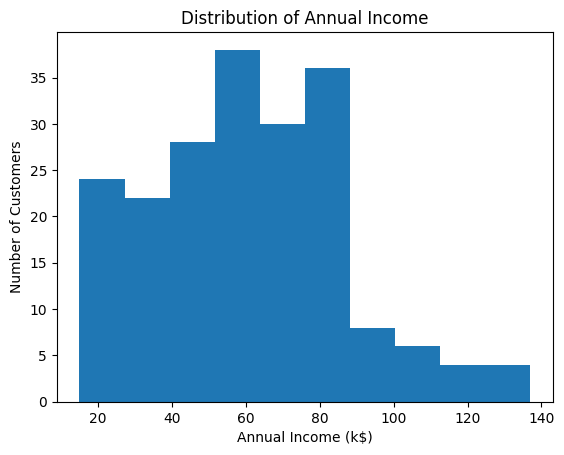

In [10]:
import matplotlib.pyplot as plt

plt.hist(data["Annual Income (k$)"], bins=10)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Annual Income")
plt.show()

#### Spending scores

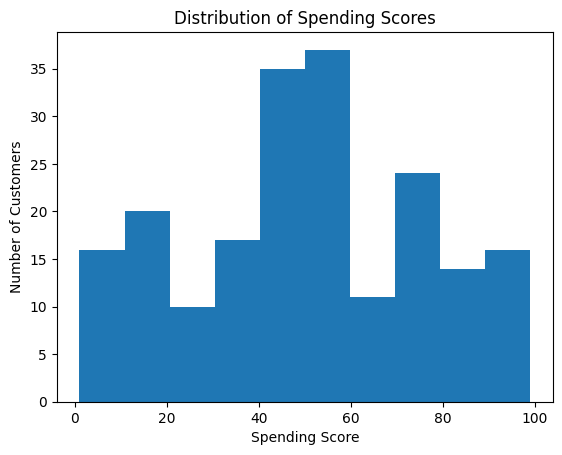

In [11]:
plt.hist(data["Spending Score (1-100)"], bins=10)
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")
plt.title("Distribution of Spending Scores")
plt.show()

#### Annual Income VS Spending Scores

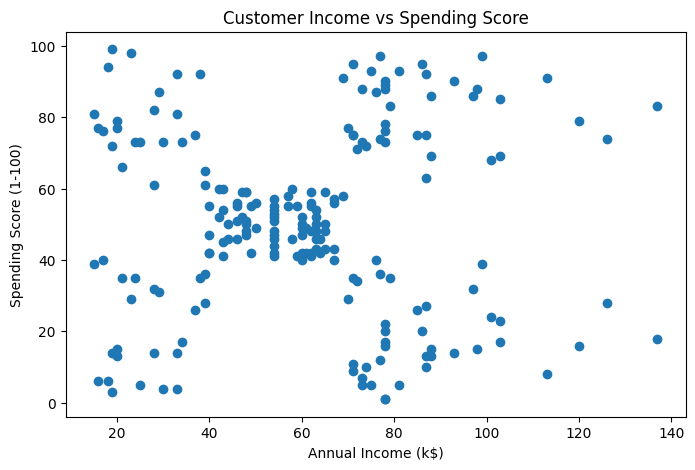

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    data["Annual Income (k$)"],
    data["Spending Score (1-100)"]
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Income vs Spending Score")

plt.show()

### Feature Selection

In [13]:
X = data[["Annual Income (k$)", "Spending Score (1-100)"]]

In [14]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


### Feature Scaling

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

### Finding the Optimal Number of Clusters using the Elbow Method

In [17]:
from sklearn.cluster import KMeans
wcss = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

#### Plotting the elbow graph

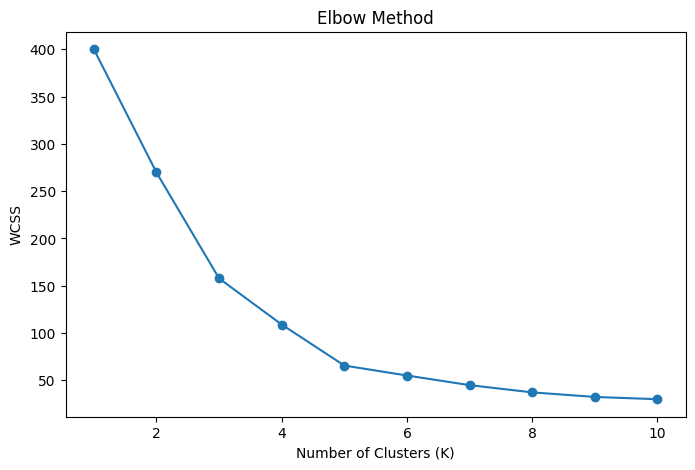

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), wcss, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

### Building the K-Means Clustering Model

In [19]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)

#### Visualizing Customer Clusters

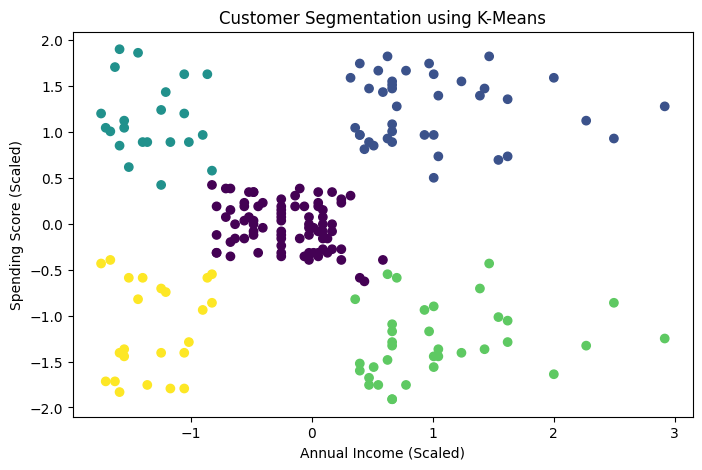

In [20]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=y_kmeans,
    cmap="viridis"
)

plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.title("Customer Segmentation using K-Means")
plt.show()

#### Visulaizing Cluster Centroids

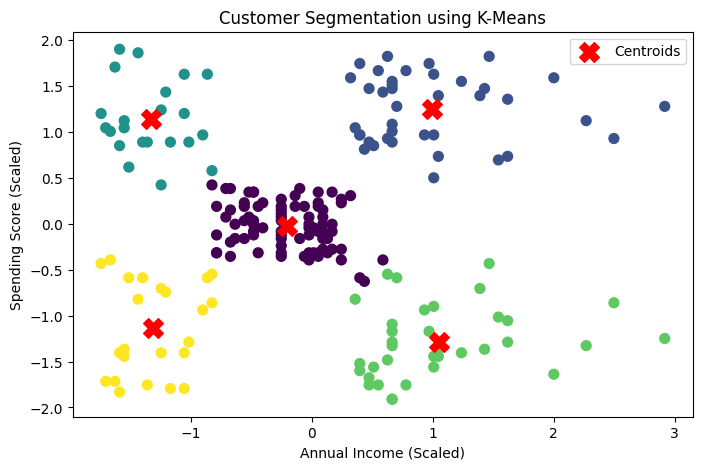

In [22]:
plt.figure(figsize=(8, 5))
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=y_kmeans,
    cmap="viridis",
    s=50
)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200,
    c="red",
    marker="X",
    label="Centroids"
)
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.show()

#### Assigning Cluster Labels to Customers

In [23]:
data["Cluster"] = y_kmeans
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


#### Analyzing Customer Sgements

In [24]:
cluster_summary = data.groupby("Cluster")[
    ["Annual Income (k$)", "Spending Score (1-100)"]
].mean().round(2)

cluster_summary

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.30,49.52
1,86.54,82.13
2,25.73,79.36
3,88.20,17.11
4,26.30,20.91


### Cluster Summary and Cluster Ranges

In [30]:
for cluster in sorted(data["Cluster"].unique()):
    group = data[data["Cluster"] == cluster]

    income_min = group["Annual Income (k$)"].min() * 1000
    income_max = group["Annual Income (k$)"].max() * 1000

    score_min = group["Spending Score (1-100)"].min()
    score_max = group["Spending Score (1-100)"].max()

    print(f"\nCluster {cluster}")
    print(f"Annual Income: ${income_min:,.0f} - ${income_max:,.0f}")
    print(f"Spending Score: {score_min:.0f} - {score_max:.0f}")


Cluster 0
Annual Income: $39,000 - $76,000
Spending Score: 34 - 61

Cluster 1
Annual Income: $69,000 - $137,000
Spending Score: 63 - 97

Cluster 2
Annual Income: $15,000 - $39,000
Spending Score: 61 - 99

Cluster 3
Annual Income: $70,000 - $137,000
Spending Score: 1 - 39

Cluster 4
Annual Income: $15,000 - $39,000
Spending Score: 3 - 40


### Customer Distribution Analysis

#### Counting Customers in Each Cluster

In [25]:
cluster_counts = data["Cluster"].value_counts().sort_index()
print(cluster_counts)

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


#### Visualizing the Customer Distribution

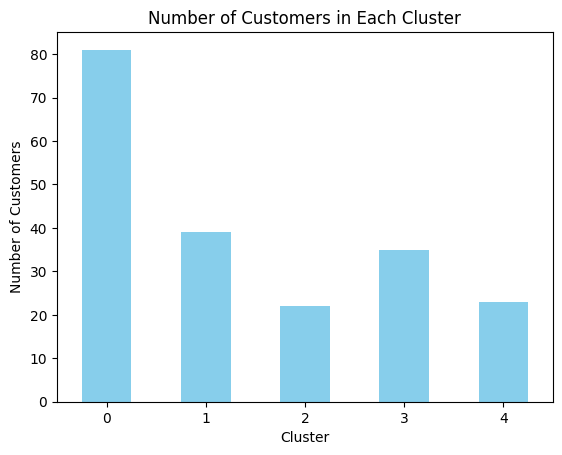

In [26]:
cluster_counts.plot(kind="bar", color="skyblue")

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Number of Customers in Each Cluster")
plt.xticks(rotation=0)
plt.show()

### Predicting the Cluster for a New Customer

In [31]:
new_customer = pd.DataFrame({
    "Annual Income (k$)": [90],
    "Spending Score (1-100)": [85]
})

new_customer_scaled = scaler.transform(new_customer)

predicted_cluster = kmeans.predict(new_customer_scaled)

print("Predicted Cluster:", predicted_cluster[0])

Predicted Cluster: 1


### Save the model and Scaler

In [32]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!
